# **Implementación del caso de 5 Qubits**

In [38]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q
from modules import teoria_numeros as tn

from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
seed = 99

In [40]:
N5 = 48567227

In [41]:
fiveQubit = sl.schnorrCVP(N5, 3, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 50


In [42]:
cvpinstance = fiveQubit.generate_cvp(10)

B = 
[ 2 0 0 0 0  693 ]
[ 0 1 0 0 0 1099 ]
[ 0 0 3 0 0 1609 ]
[ 0 0 0 2 0 1946 ]
[ 0 0 0 0 1 2398 ]
t = 
(0, 0, 0, 0, 0, 17698)


In [43]:
cvpResult = fiveQubit.babai_algorithm(cvpinstance, delta = 0.99)
print(f'D5 = \n{cvpResult.D}\n')
print(f'b_op5 = \n{cvpResult.b_op}\n')
print(f'res_vector5 = \n{cvpResult.res_vector}\n')
print(f'step_sign5 = \n{cvpResult.step_sign}\n')
print(f'weights5 = \n{cvpResult.weight}\n')

D5 = 
[ -4 -3 -3 4  1 -2 ]
[  0  3  0 4 -3 -5 ]
[  2 -5  0 0  2 -6 ]
[  0 -2  3 8 -3  1 ]
[  8  3 -6 2 -2  1 ]

b_op5 = 
[   -2     3     3     4     4 17697]

res_vector5 = 
[ 2 -3 -3 -4 -4  1]

step_sign5 = 
[-1 -1  1 -1  1]

weights5 = 
(81, -1837, -1255, 790, 354)



In [44]:
qubo5 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, fiveQubit.n)
print(qubo5.prettyprint())

Hc5, offset5 = q.define_hamiltonian(qubo5)
print(f'Offset = {offset5}')
print(f'Hamiltonian = \n{Hc5}')

Problem name: quboProblem

Minimize
  55*z_0^2 + 28*z_0*z_1 - 42*z_0*z_2 + 48*z_0*z_3 + 38*z_0*z_4 + 59*z_1^2
  - 18*z_1*z_2 + 60*z_1*z_3 - 36*z_1*z_4 + 69*z_2^2 + 4*z_2*z_3 - 18*z_2*z_4
  + 87*z_3^2 + 2*z_3*z_4 + 118*z_4^2 - 24*z_0 - 36*z_1 - 10*z_2 - 44*z_3
  - 52*z_4 + 55

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4

Offset = 182.5
Hamiltonian = 
SparsePauliOp(['IIIIZ', 'IIZII', 'ZIIII', 'IIIZI', 'IZIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-33.5+0.j, -11. +0.j, -29.5+0.j, -20. +0.j, -50. +0.j,   7. +0.j,
 -10.5+0.j,  12. +0.j,   9.5+0.j,  -4.5+0.j,  15. +0.j,  -9. +0.j,
   1. +0.j,  -4.5+0.j,   0.5+0.j])


In [45]:
formatted_h = " + ".join([f"{c.real:.3f}{s}" for s, c in Hc5.label_iter()])
print(formatted_h)

-33.500IIIIZ + -11.000IIZII + -29.500ZIIII + -20.000IIIZI + -50.000IZIII + 7.000IIIZZ + -10.500IIZIZ + 12.000IZIIZ + 9.500ZIIIZ + -4.500IIZZI + 15.000IZIZI + -9.000ZIIZI + 1.000IZZII + -4.500ZIZII + 0.500ZZIII


In [46]:
circuit5 = q.construct_circuit(Hc5, reps= 1)
print(circuit5)

     ┌───┐ ┌────────────────┐                                             »
q_0: ┤ H ├─┤ Rz((-67)*γ[0]) ├─■─────────────■────────────────■────────────»
     ├───┤ ├────────────────┤ │ZZ(14*γ[0])  │                │            »
q_1: ┤ H ├─┤ Rz((-40)*γ[0]) ├─■─────────────┼────────────────┼────────────»
     ├───┤ ├────────────────┤               │ZZ((-21)*γ[0])  │            »
q_2: ┤ H ├─┤ Rz((-22)*γ[0]) ├───────────────■────────────────┼────────────»
     ├───┤┌┴────────────────┤                                │ZZ(24*γ[0]) »
q_3: ┤ H ├┤ Rz((-100)*γ[0]) ├────────────────────────────────■────────────»
     ├───┤└┬────────────────┤                                             »
q_4: ┤ H ├─┤ Rz((-59)*γ[0]) ├─────────────────────────────────────────────»
     └───┘ └────────────────┘                                             »
«                                   ┌────────────┐                 »
«q_0: ─────────────────■────────────┤ Rx(2*β[0]) ├─────────────────»
«                      │  

In [47]:
x0 = np.asarray([0.0]*circuit5.num_parameters)
#x0 = np.random.uniform(0, 2*np.pi, circuit5.num_parameters)
monitor, optParameters10 = q.qaoa_algorithm(circuit5, Hc5, x0)

In [48]:
print(f'Iteraciones = {monitor.iteration}')
print(f'Evolucion: ')
for angles, value in zip(monitor.parameters, monitor.evaluation):
    print(f'{angles}: {value}')

Iteraciones = 56
Evolucion: 
[ 0.000375 -0.0005  ]: -0.004869510072088305
[ 0.000375 -0.0005  ]: -0.004869510072088305
[ 0.00075 -0.0015 ]: -0.02909822258680001
[ 0.0014375 -0.002    ]: -0.07409538061090916
[ 0.00253125 -0.00425   ]: -0.2693880210470418
[ 0.00445313 -0.006375  ]: -0.6785138926263258
[ 0.00760156 -0.0119375 ]: -1.7507883802280235
[ 0.01301953 -0.01896875]: -2.935451948581919
[ 0.01301953 -0.01896875]: -2.935451948581919
[ 0.01301953 -0.01896875]: -2.935451948581919
[ 0.01301953 -0.01896875]: -2.935451948581919
[ 0.01301953 -0.01896875]: -2.935451948581919
[ 0.01350391 -0.01859375]: -3.082876849065521
[ 0.01350391 -0.01859375]: -3.082876849065521
[ 0.01526367 -0.02032813]: -3.2513201391272055
[ 0.01508887 -0.01788281]: -3.5143543987537798
[ 0.018521   -0.02012891]: -3.978148427420418
[ 0.01988745 -0.01636133]: -4.759599717724148
[ 0.02743494 -0.01896973]: -6.15811924756759
[ 0.03394159 -0.01273877]: -7.932579927707833
[ 0.05228989 -0.01484009]: -12.465778547994002
[ 0.05

In [49]:
for param in optParameters10.items():
    print(f'{param[0]} = {param[1]}')

β[0] = 0.6505061267065428
γ[0] = -0.01589582783491532


In [50]:
results5= q.sample_from_parameters(circuit5, optParameters10, shots = 10_000)
print(len(results5))
for bitstring, count in results5.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

31
Bistring: 00000 -> Counts: 3706
Bistring: 00100 -> Counts: 1425
Bistring: 00010 -> Counts: 870
Bistring: 00101 -> Counts: 622
Bistring: 00110 -> Counts: 495
Bistring: 01000 -> Counts: 417
Bistring: 10010 -> Counts: 374
Bistring: 00001 -> Counts: 340
Bistring: 10000 -> Counts: 339
Bistring: 10110 -> Counts: 295
Bistring: 10100 -> Counts: 209
Bistring: 01100 -> Counts: 121
Bistring: 00011 -> Counts: 115
Bistring: 00111 -> Counts: 89
Bistring: 01010 -> Counts: 73
Bistring: 01001 -> Counts: 72
Bistring: 10001 -> Counts: 70
Bistring: 01111 -> Counts: 65
Bistring: 01011 -> Counts: 63
Bistring: 01110 -> Counts: 55
Bistring: 11000 -> Counts: 39
Bistring: 01101 -> Counts: 39
Bistring: 11100 -> Counts: 33
Bistring: 10011 -> Counts: 19
Bistring: 11001 -> Counts: 19
Bistring: 11111 -> Counts: 13
Bistring: 11101 -> Counts: 6
Bistring: 11110 -> Counts: 6
Bistring: 11010 -> Counts: 4
Bistring: 10111 -> Counts: 4
Bistring: 11011 -> Counts: 3


In [51]:
nD5 = sl.integer_to_matrix(cvpResult.D)
vnew5 = sl.bitstring2latticeVectors(nD5, results5.keys(), cvpResult.step_sign, cvpResult.b_op)

In [52]:
distances5 = utils.get_distances(vnew5, cvpinstance.t)

In [53]:
nB5 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs5 = sl.vectors2uv_pairs(nB5, vnew5, fiveQubit.n)
for pair5 in uv_pairs5:
    print(pair5)

[96850215 2]
[434032445 9]
[97435855 2]
[48315300 1]
[11789738455 243]
[4735382553 98]
[243509112 5]
[48514950 1]
[242045496 5]
[2182563152 45]
[241049424 5]
[2357947691 49]
[2391607350 49]
[21435888100 441]
[233436821409 4802]
[116232117210 2401]
[48498912 1]
[5706233412220 117649]
[5729812889130 117649]
[3138428376721 64827]
[8453244888 175]
[115753795740 2401]
[8418457872 175]
[341545248 7]
[82995495264 1715]
[4074533610048 84035]
[82653950016 1715]
[414998793616 8575]
[416713664664 8575]
[340139712 7]
[4091370525792 84035]


In [54]:
sr_pairs5 = sl.uv_pairs2sr_pairs(uv_pairs5, fiveQubit)
print(sr_pairs5)

[((96850215, 2), -284239), ((97435855, 2), 301401), ((11789738455, 243), -12097706)]


In [55]:
probs5 = utils.get_probs(results5.values(), shots = 10_000)

In [56]:
utils.prettyprint(vnew5, distances5, probs5, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [   -2     3     3     4     4 17697]

El vector residual 
t - b_op = [ 2 -3 -3 -4 -4  1]

La distancia |t - b_op| = 7.416

0: Prob = 0.37060
	vnew = [   -2     3     3     4     4 17697] con distancia: 7.416
1: Prob = 0.14250
	vnew = [    0    -2     3     4     6 17691] con distancia: 10.677
2: Prob = 0.08700
	vnew = [   -2     0     3     0     7 17702] con distancia: 8.832
3: Prob = 0.06220
	vnew = [    4     1     6     0     5 17693] con distancia: 10.149
4: Prob = 0.04950
	vnew = [    0    -5     3     0     9 17696] con distancia: 10.909
5: Prob = 0.04170
	vnew = [   -2     5     0    -4     7 17696] con distancia: 9.899
6: Prob = 0.03740
	vnew = [    6     3    -3     2     5 17703] con distancia: 10.392
7: Prob = 0.03400
	vnew = [    2     6     6     0     3 17699] con distancia: 9.274
8: Prob = 0.03390
	vnew = [    6     6    -3     6     2 17698] con distancia: 11.000
9: Prob = 0.02950
	vnew = [    8    -2    -3     2     7 

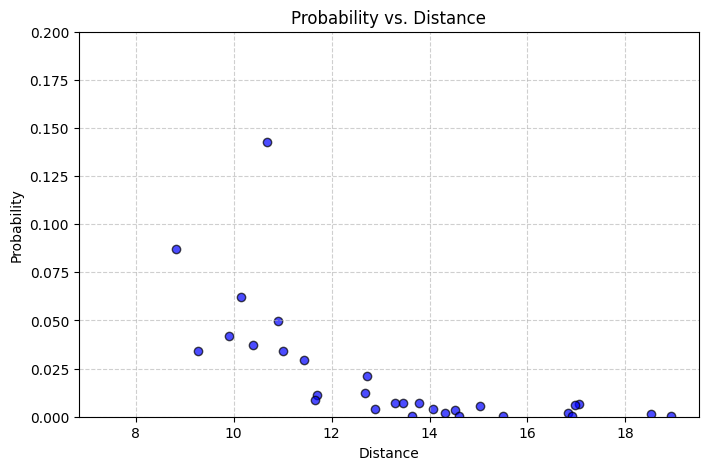

In [57]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances5, probs5, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.2) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()